# 00 - Data Ingestion and Quality

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from stylin import InfoDisplayStyler


In [2]:
DATA_PATH = '../../data/raw/ethusdt_1h.csv'

raw_data = pd.read_csv(DATA_PATH)
assert not raw_data.empty, "DataFrame is empty"

### 1. Raw data overview.

In [3]:
raw_data["timestamp"] = pd.to_datetime(raw_data["timestamp"], errors="coerce", utc=True)

def column_summary(data):
    def classify_dtype(dtype):
        if pd.api.types.is_datetime64_any_dtype(dtype):
            return "datetime"
        if pd.api.types.is_numeric_dtype(dtype):
            return "numerical"
        if pd.api.types.is_bool_dtype(dtype):
            return "bool"
        return "categorical"

    out = data.dtypes.rename("dtype").to_frame()
    out["type"] = out["dtype"].apply(classify_dtype)
    return out.reset_index().rename(columns={"index": "column"})


styler = InfoDisplayStyler()

styler.show_meta(raw_data)
styler.style_me(column_summary(raw_data), title="Columns characteristics")
styler.style_me(raw_data.head(10), title="Head 10")
styler.style_me(raw_data.tail(10), title="Tail 10")
styler.style_me(raw_data.describe(), title="Describe")

,column,dtype,type
0,timestamp,"datetime64[us, UTC]",datetime
1,open,float64,numerical
2,high,float64,numerical
3,low,float64,numerical
4,close,float64,numerical
5,volume,float64,numerical
6,quote_asset_volume,float64,numerical
7,number_of_trades,int64,numerical
8,taker_buy_base_asset_volume,float64,numerical
9,taker_buy_quote_asset_volume,float64,numerical


,timestamp,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
0,2021-01-01 00:00:00+00:00,736.420000,739.000000,729.330000,734.070000,27932.698840,20479903.476036,22671,15020.616630,11015918.972215
1,2021-01-01 01:00:00+00:00,734.080000,749.000000,733.370000,748.280000,52336.187790,38899618.853014,41712,27395.902700,20362373.933503
2,2021-01-01 02:00:00+00:00,748.270000,749.000000,742.270000,744.060000,33019.501000,24606726.438367,19566,17721.266960,13207123.352084
3,2021-01-01 03:00:00+00:00,744.060000,747.230000,743.100000,744.820000,17604.808590,13119088.400414,12230,9499.749200,7079926.310875
4,2021-01-01 04:00:00+00:00,744.870000,747.090000,739.300000,742.290000,18794.154240,13980190.971469,13626,10133.742110,7539500.286872
5,2021-01-01 05:00:00+00:00,742.340000,743.230000,739.500000,740.650000,14948.264470,11079350.239027,11032,7733.141620,5731472.415792
6,2021-01-01 06:00:00+00:00,740.720000,743.250000,737.040000,739.970000,17106.994950,12658465.389902,12041,7803.152170,5774894.281794
7,2021-01-01 07:00:00+00:00,739.870000,740.510000,734.400000,737.380000,21624.689450,15934710.936921,19976,10407.773120,7670628.229733
8,2021-01-01 08:00:00+00:00,737.370000,738.480000,725.100000,730.070000,52992.048920,38713139.835248,38433,23184.477150,16937333.067966
9,2021-01-01 09:00:00+00:00,730.070000,734.770000,728.770000,733.680000,22836.469730,16732025.025702,27347,12351.595690,9050056.598467


,timestamp,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
46248,2026-04-12 14:00:00+00:00,2186.980000,2193.530000,2178.690000,2180.860000,16800.014500,36742502.318081,139893,8708.739900,19056153.060002
46249,2026-04-12 15:00:00+00:00,2180.880000,2188.890000,2175.000000,2186.470000,8622.289800,18812627.870871,85325,4330.988200,9452335.972126
46250,2026-04-12 16:00:00+00:00,2186.470000,2190.430000,2183.090000,2187.090000,4674.392700,10221220.676962,53716,2211.334000,4836474.381929
46251,2026-04-12 17:00:00+00:00,2187.090000,2205.000000,2187.090000,2203.170000,7545.517800,16572546.479858,80626,5065.404700,11125578.704893
46252,2026-04-12 18:00:00+00:00,2203.180000,2207.230000,2199.560000,2200.600000,5588.703200,12312160.688884,59534,2846.483200,6271431.084932
46253,2026-04-12 19:00:00+00:00,2200.600000,2205.200000,2197.400000,2198.270000,3607.896400,7943679.940291,34095,1183.271700,2605119.462321
46254,2026-04-12 20:00:00+00:00,2198.270000,2218.130000,2193.340000,2213.530000,8794.323500,19405465.554551,91423,4870.542700,10751377.632031
46255,2026-04-12 21:00:00+00:00,2213.540000,2217.710000,2205.190000,2211.240000,4865.707000,10752186.398283,72652,2352.928200,5199984.800300
46256,2026-04-12 22:00:00+00:00,2211.240000,2211.260000,2183.990000,2199.370000,16989.266800,37276685.136970,284928,8753.078700,19208384.530221
46257,2026-04-12 23:00:00+00:00,2199.360000,2199.360000,2186.350000,2191.650000,6791.123400,14878825.922920,126484,2650.260600,5805765.305386


,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
count,46258.000000,46258.000000,46258.000000,46258.000000,46258.000000,46258.000000,46258.000000,46258.000000,46258.000000
mean,2524.952429,2538.390068,2510.628101,2524.983168,24212.140293,57952041.462612,79831.403217,12035.602735,28792661.646080
std,895.591448,899.979862,890.755172,895.554914,26921.186268,63019617.585606,103262.037990,13383.045418,31235334.296589
min,719.900000,728.280000,714.290000,719.900000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1803.652500,1810.647500,1794.560000,1803.717500,9172.685275,21569717.785864,24075.250000,4506.296650,10629820.801122
50%,2423.050000,2437.470000,2409.510000,2423.050000,15964.745100,39751259.827815,43433.500000,7954.393500,19739854.503078
75%,3195.302500,3214.700000,3175.045000,3195.300000,29328.078128,71115054.996182,92221.000000,14565.056800,35398951.375526
max,4935.010000,4956.780000,4897.310000,4935.000000,508838.404900,1508981031.835180,3460538.000000,239587.993800,749215345.372224


### Data description:

| Kolumna | Znaczenie | (predykcja `sell/hold/buy`) |
|---|---|---|
| `timestamp` | Czas zamknięcia świecy 1h (UTC). | Klucz do porządku czasowego, splitu chronologicznego i cech kalendarzowych (`hour`, `dayofweek`). |
| `open` | Cena ETH/USDT na początku godziny. | Pomaga opisać kierunek świecy i momentum (np. `close_open_pct`). |
| `high` | Najwyższa cena w tej godzinie. | Informacja o maksymalnym ruchu i zmienności intrahour. |
| `low` | Najniższa cena w tej godzinie. | Razem z `high` daje zakres świecy (`high_low_pct`), ważny dla oceny ryzyka/zmienności. |
| `close` | Cena na końcu godziny. | Najważniejsza kolumna do targetu (`future_return`) i większości cech trendu/zwrotów. |
| `volume` | Wolumen ETH (ile ETH przeszło w tej godzinie). | Mówi o sile ruchu; skoki wolumenu często poprzedzają większe ruchy ceny. |
| `quote_asset_volume` | Wolumen w USDT (wartość obrotu). | Pokazuje realny „kapitał” wchodzący w rynek; często bardzo informacyjna cecha. |
| `number_of_trades` | Liczba transakcji w godzinie. | Proxy aktywności rynku/mikrostruktury; pomaga odróżnić spokojne vs nerwowe okresy. |
| `taker_buy_base_asset_volume` | Wolumen ETH kupiony agresywnie (zlecenia market buy). | Sygnał presji kupna; przydatny do oceny przewagi popytu. |
| `taker_buy_quote_asset_volume` | To samo co wyżej, ale wartość w USDT. | Czasem stabilniejszy niż wolumen w ETH, bo zależy od wartości transakcji. |


### Thoughts about raw data:

- Zbiór zawiera 46 258 rekordów i 10 kolumn z danymi OHLCV oraz metadanymi transakcyjnymi. 
- Zakres czasowy obejmuje okres od 2021-01-01 00:00:00 UTC do 2026-04-12 23:00:00 UTC, co daje długi i wartościowy horyzont do modelowania. 
- Struktura tabeli jest spójna z oczekiwanym formatem dla danych giełdowych 1h. 
- Dane wejściowe są wystarczająco duże i bogate, aby przejść do dalszych etapów pipeline’u.

### 2. Data quality checks


In [4]:
quality_table = pd.DataFrame(
    {
        "missing_values": raw_data.isna().sum(),
        "dtype": raw_data.dtypes.astype(str),
    }
)

duplicate_rows = int(raw_data.duplicated().sum())
duplicate_timestamps = int(raw_data["timestamp"].duplicated().sum())

styler.show_line(duplicate_rows, title="Duplicate rows")
styler.show_line(duplicate_timestamps, title="Duplicate timestamps")
styler.style_me(quality_table, title='Quality table')

,missing_values,dtype
timestamp,0,"datetime64[us, UTC]"
open,0,float64
high,0,float64
low,0,float64
close,0,float64
volume,0,float64
quote_asset_volume,0,float64
number_of_trades,0,int64
taker_buy_base_asset_volume,0,float64
taker_buy_quote_asset_volume,0,float64


### After thoughts:

- Nie wykryto braków danych ani duplikatów rekordów/timestampów, co potwierdza wysoką jakość wejścia. 
- Typy kolumn są zgodne z ich przeznaczeniem po konwersji timestamp do datetime i kolumn cenowo-wolumenowych do typu numerycznego. 
- Na tym etapie nie ma potrzeby agresywnego czyszczenia danych. 
- Zbiór można bezpiecznie przekazać do dalszej walidacji czasowej i integralności świec.

### 3. Timestamp checks


In [6]:
ts = pd.to_datetime(raw_data["timestamp"], utc=True, errors="coerce")

is_monotonic_before = ts.is_monotonic_increasing

tmp = raw_data.copy()
tmp["timestamp"] = ts
tmp = tmp.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

is_monotonic_after = tmp["timestamp"].is_monotonic_increasing

monotonic_report = pd.DataFrame(
    {
        "is_monotonic_before_sort": [is_monotonic_before],
        "is_monotonic_after_sort": [is_monotonic_after],
    }
)
styler.style_me(monotonic_report, title="Timestamp monotonicity report")

,is_monotonic_before_sort,is_monotonic_after_sort
0,True,True


,min_timestamp,max_timestamp,non_null_count,unique_count,missing_count,duplicate_count
0,2021-01-01 00:00:00+00:00,2026-04-12 23:00:00+00:00,46258,46258,0,0


,total_intervals,non_1h_intervals,pct_non_1h,min_diff,max_diff,mode_diff
0,46257,7,0.015133,0 days 01:00:00,0 days 05:00:00,0 days 01:00:00


,timestamp,prev_timestamp,delta
988,2021-02-11 05:00:00+00:00,2021-02-11 03:00:00,0 days 02:00:00
1537,2021-03-06 03:00:00+00:00,2021-03-06 01:00:00,0 days 02:00:00
2616,2021-04-20 04:00:00+00:00,2021-04-20 01:00:00,0 days 03:00:00
2737,2021-04-25 08:00:00+00:00,2021-04-25 04:00:00,0 days 04:00:00
5371,2021-08-13 06:00:00+00:00,2021-08-13 01:00:00,0 days 05:00:00
6500,2021-09-29 09:00:00+00:00,2021-09-29 06:00:00,0 days 03:00:00
19488,2023-03-24 14:00:00+00:00,2023-03-24 12:00:00,0 days 02:00:00


C:\Users\ankap\AppData\Local\Temp\ipykernel_76708\3803157162.py:42: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  obs_per_month = ts.dropna().dt.to_period("M").value_counts().sort_index()


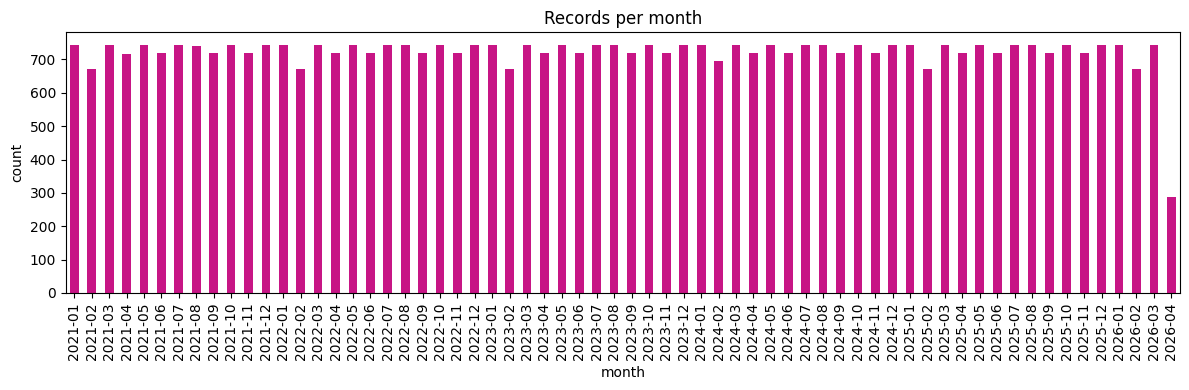

In [7]:
ts = pd.to_datetime(raw_data["timestamp"], utc=True, errors="coerce")

ts_info = pd.DataFrame(
    {
        "min_timestamp": [ts.min()],
        "max_timestamp": [ts.max()],
        "non_null_count": [int(ts.count())],
        "unique_count": [int(ts.nunique())],
        "missing_count": [int(ts.isna().sum())],
        "duplicate_count": [int(ts.duplicated().sum())],
    }
)
styler.style_me(ts_info)



ts_sorted = tmp["timestamp"]
delta = ts_sorted.diff()

expected = pd.Timedelta(hours=1)
non_1h_mask = delta.notna() & (delta != expected)

diff_report = pd.DataFrame(
    {
        "total_intervals": [int(delta.notna().sum())],
        "non_1h_intervals": [int(non_1h_mask.sum())],
        "pct_non_1h": [float(non_1h_mask.mean() * 100)],
        "min_diff": [delta.min()],
        "max_diff": [delta.max()],
        "mode_diff": [delta.mode().iloc[0] if not delta.mode().empty else pd.NaT],
    }
)
styler.style_me(diff_report, title="Timestamp interval quality (expected 1h)")

deviations_preview = tmp.loc[non_1h_mask, ["timestamp"]].copy()
deviations_preview["prev_timestamp"] = ts_sorted.shift(1)[non_1h_mask].values
deviations_preview["delta"] = delta[non_1h_mask].values
styler.style_me(deviations_preview.head(20), title="Examples of non-1h intervals")



obs_per_month = ts.dropna().dt.to_period("M").value_counts().sort_index()
plt.figure(figsize=(12, 4))
obs_per_month.plot(kind="bar", color='mediumvioletred')
plt.title("Records per month")
plt.xlabel("month")
plt.ylabel("count")
plt.tight_layout()
plt.show()

### Timestamp info

- Znaczniki czasu są poprawnie uporządkowane (seria jest monotonicznie rosnąca), więc dane zachowują prawidłową kolejność chronologiczną do analizy szeregów czasowych.  
- Wykryto łącznie **7 odchyleń od kroku 1h** na **46 257 interwałów** (~**0.015%**), co oznacza bardzo dobrą ciągłość danych.
- Pełny reindex godzinowy pokazał **14 brakujących godzin**. 
- Największa pojedyncza luka ma **5h** i wynika z braku godzin `02:00–05:00` dnia `2021-08-13` (czyli odstęp między istniejącymi rekordami to `01:00 -> 06:00`).
- Skala braków jest mała i nie dyskwalifikuje zbioru, ale może lokalnie wpływać na cechy czasowe, bo część „kroków 1h” może faktycznie odpowiadać dłuższemu odstępowi czasowemu.  

### 4. Candle integrity checks


In [8]:
num_df = raw_data.copy()
for col in ["open", "high", "low", "close", "volume"]:
    num_df[col] = pd.to_numeric(num_df[col], errors="coerce")

invalid_high = int((num_df["high"] < num_df[["open", "close"]].max(axis=1)).sum())
invalid_low = int((num_df["low"] > num_df[["open", "close"]].min(axis=1)).sum())
negative_volume = int((num_df["volume"] < 0).sum())

candles_integrity = pd.DataFrame(
    {
        "invalid_high": [invalid_high],
        "invalid_low": [invalid_low],
        "negative_volume": [negative_volume],
    }
)
styler.style_me(candles_integrity)

,invalid_high,invalid_low,negative_volume
0,0,0,0


### Candle thoughs:
- Dane świecowe spełniają podstawowe warunki spójności rynkowej: nie wykryto ani jednego przypadku invalid_high, invalid_low oraz negative_volume. 
- Relacje między open, high, low, close są logicznie poprawne i nie zawierają anomalii typu „high poniżej ceny otwarcia/zamknięcia” lub „low powyżej ceny otwarcia/zamknięcia”. - Brak ujemnego wolumenu dodatkowo potwierdza poprawność techniczną rekordów transakcyjnych. 
- Na tym etapie nie ma potrzeby usuwania rekordów z powodu niespójności świec. 

### Summary of notebook:

- Dane wejściowe mają wysoką jakość i są gotowe do dalszego pipeline’u. 
- Jedyny istotny element do jawnej obsługi to pojedyncze luki czasowe (7 interwałów nie-1h), które należy uwzględnić przed feature engineeringiem zależnym od czasu. 
- Poza tym zbiór nie wykazuje problemów krytycznych (braki, duplikaty, błędy integralności świec).